# Extra analysis

Supplementary analysis. It looks at
- why the heuristic baseline wouldn't work as a substitute for the SARSOP optimum,
- decision boundaries over the belief simplex for value-based decentralized policies
- Periodicity in IACC-PS policies across training instances

All of it runs off cached rollout data and trained checkpoints, no retraining needed.

The rollout data (`results/data/rollout_data/`) and checkpoints come from Zenodo via `download_artifacts.sh`. The belief-simplex and IACC-PS sections also need per-seed rollouts in `results/data/rollout_data_all_seeds/`, which are not on Zenodo; generate them with `python results/get_rollout_data.py --all-seeds --episodes 100`.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

import imprl.envs

np.set_printoptions(suppress=True, precision=3)
sns.set_theme(
    context="paper", style="whitegrid", font_scale=1.5, font="Times New Roman"
)

# Paths (work whether the notebook is run from the repo root or from results/).
RESULTS_DIR = Path("results") if Path("results").is_dir() else Path(".")
REPO_ROOT = RESULTS_DIR.resolve().parent
ROLLOUT_ROOT = RESULTS_DIR / "data" / "rollout_data" / "k_out_of_n_infinite"
ALL_SEEDS_ROOT = RESULTS_DIR / "data" / "rollout_data_all_seeds" / "k_out_of_n_infinite"
FIG_DIR = RESULTS_DIR / "figures" / "extra_analysis"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# k-out-of-4 settings, ordered from most redundant (parallel) to least (series).
SETTINGS = [f"hard-{k}-of-4_infinite" for k in range(1, 5)]
SETTING_NAMES = {s: f"{k}-of-4" for k, s in zip(range(1, 5), SETTINGS)}
K_OF = {s: (k, 4) for k, s in zip(range(1, 5), SETTINGS)}

ACTION_LABELS = {0: "do-nothing", 1: "repair", 2: "inspect"}
DO_NOTHING, REPAIR, INSPECT = 0, 1, 2

# Decentralized MARL algorithms compared throughout, plus the optimal reference.
OPTIMAL = "SARSOP"
MARL_ALGS = ["MAPPO_PS", "IPPO_PS", "IACC_PS", "IAC_PS", "DCMAC", "QMIX_PS", "VDN_PS"]
ALG_NAMES = {
    "DCMAC": "DCMAC",
    "IACC_PS": "IACC-PS",
    "MAPPO_PS": "MAPPO-PS",
    "QMIX_PS": "QMIX-PS",
    "VDN_PS": "VDN-PS",
    "IAC_PS": "IAC-PS",
    "IPPO_PS": "IPPO-PS",
}
# Same hex values as the main boxplot figure (tab10 @ alpha=0.9 over white),
# so colours match across figures in the paper.
ALG_COLORS = {
    "DDQN": "#3274a1",
    "JAC": "#e1812c",
    "DCMAC": "#3a923a",
    "IACC_PS": "#c03d3e",
    "MAPPO_PS": "#9372b2",
    "QMIX_PS": "#845b53",
    "VDN_PS": "#d684bd",
    "IAC_PS": "#7f7f7f",
    "IPPO_PS": "#a9aa35",
}

# Best (lowest-cost) training run per (setting, algorithm) -- the shared
# source of truth for every cost/regret comparison below.
summary = pd.read_csv(RESULTS_DIR / "data" / "results_summary.csv")
best = summary.loc[summary.groupby(["setting", "algorithm"])["best_cost"].idxmin()]
PLOT_ALGS = [a for a in ALG_NAMES if a in summary.algorithm.unique()]

# Analytical/Monte Carlo baselines (SARSOP, inspect-and-repair heuristic) per setting.
BASELINES = {
    s: imprl.envs.make("k_out_of_n_infinite", s).core.baselines for s in SETTINGS
}

In [2]:
def load_rollouts(setting, alg):
    """Load per-episode rollout dicts for one (setting, algorithm), or None if missing."""
    path = ROLLOUT_ROOT / setting / alg / "rollout_data.pkl"
    if not path.exists():
        return None
    with open(path, "rb") as f:
        d = pickle.load(f)
    return [d[k] for k in sorted(d.keys())]


def stack(rollouts, key):
    """Stack a per-episode array field into shape (n_episodes, ...)."""
    return np.asarray([r[key] for r in rollouts])


# Which algorithms actually have cached rollouts for each setting.
available = {
    s: [
        a
        for a in [OPTIMAL] + MARL_ALGS
        if (ROLLOUT_ROOT / s / a / "rollout_data.pkl").exists()
    ]
    for s in SETTINGS
}
for s in SETTINGS:
    print(f"{SETTING_NAMES[s]:>8}: {available[s]}")

  1-of-4: ['SARSOP', 'MAPPO_PS', 'IPPO_PS', 'IACC_PS', 'IAC_PS', 'DCMAC', 'QMIX_PS', 'VDN_PS']
  2-of-4: ['SARSOP', 'MAPPO_PS', 'IPPO_PS', 'IACC_PS', 'IAC_PS', 'DCMAC', 'QMIX_PS', 'VDN_PS']
  3-of-4: ['SARSOP', 'MAPPO_PS', 'IPPO_PS', 'IACC_PS', 'IAC_PS', 'DCMAC', 'QMIX_PS', 'VDN_PS']
  4-of-4: ['SARSOP', 'MAPPO_PS', 'IPPO_PS', 'IACC_PS', 'IAC_PS', 'DCMAC', 'QMIX_PS', 'VDN_PS']


## Price of decentralization vs. redundancy

Using a heuristic baseline (instead of SARSOP) would report an opposite of the actual trend.

Thin lines are individual algorithms; the thick black line is their mean.

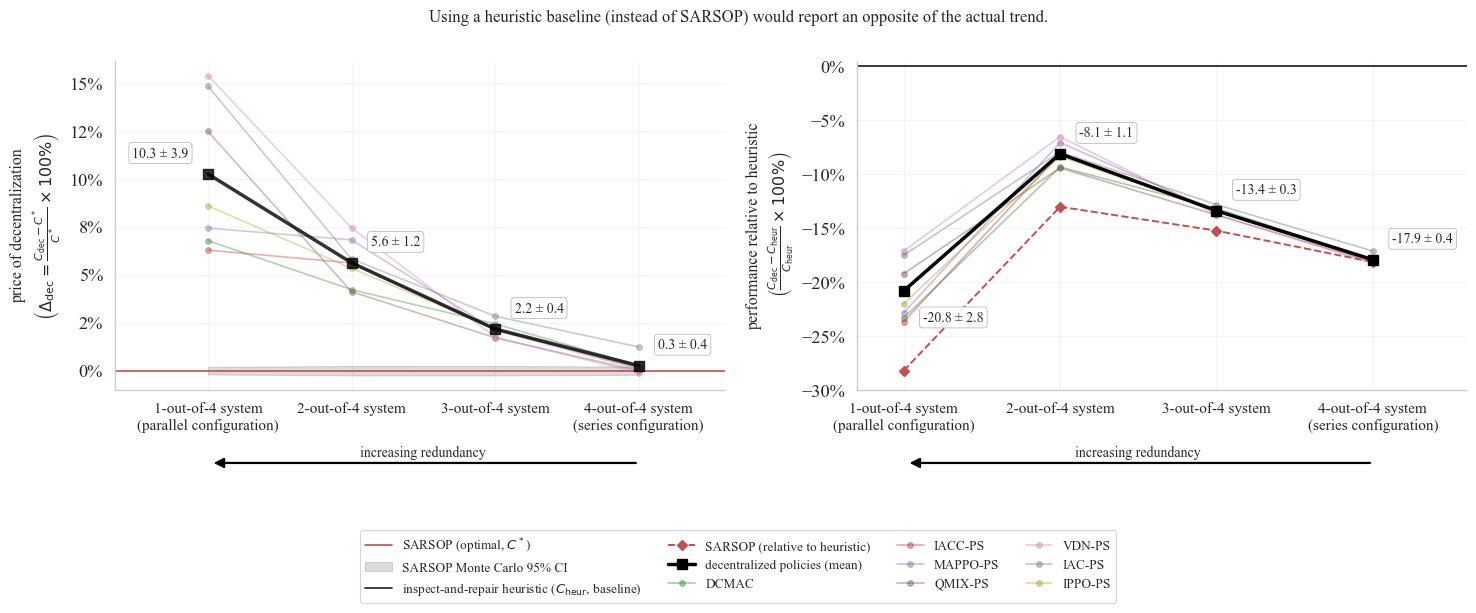

In [3]:
kn = best[best.setting.isin(SETTINGS)].copy()
kn["setting_name"] = kn.setting.map(SETTING_NAMES)
regret = kn.pivot_table(
    index="algorithm", columns="setting_name", values="normalized_best_cost"
)
order = [SETTING_NAMES[s] for s in SETTINGS]
regret = regret[order] * 100  # Delta_dec, in percent

h_heur = pd.Series({s: BASELINES[s]["InspectRepair"]["mean"] for s in SETTINGS})
h_costs = best[best.setting.isin(SETTINGS)].pivot_table(
    index="algorithm", columns="setting", values="best_cost"
)
h_rel = (
    h_costs[SETTINGS].div(h_heur) - 1.0
) * 100  # percent, same convention as Delta_dec
h_sarsop = (
    pd.Series({s: BASELINES[s]["SARSOP"]["mean"] for s in SETTINGS}).div(h_heur) - 1.0
) * 100
h_rel.columns = [SETTING_NAMES[s] for s in h_rel.columns]  # align labels with `order`
h_sarsop.index = [SETTING_NAMES[s] for s in h_sarsop.index]

xpos = np.arange(len(order))
config_tag = {1: "parallel configuration", 4: "series configuration"}
xlabels = [
    f"{K_OF[s][0]}-out-of-4 system"
    + (f"\n({config_tag[K_OF[s][0]]})" if K_OF[s][0] in config_tag else "")
    for s in SETTINGS
]

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: price of decentralization relative to the SARSOP optimum. ---
ax = axs[0]
for alg in PLOT_ALGS:
    ax.plot(
        xpos,
        regret.loc[alg, order].values,
        marker="o",
        markersize=4,
        lw=1.2,
        alpha=0.4,
        color=ALG_COLORS[alg],
        label=ALG_NAMES[alg],
    )
dec_mean = regret.loc[PLOT_ALGS, order].mean(axis=0).values
dec_std = regret.loc[PLOT_ALGS, order].std(axis=0).values
ax.plot(
    xpos,
    dec_mean,
    marker="s",
    markersize=7,
    lw=2.5,
    color="black",
    alpha=0.8,
    zorder=5,
    label="decentralized policies (mean)",
)
# Mean ± std next to each point; the leftmost label sits to the LEFT of its
# marker since nothing is plotted left of x=0 and the lines fan out to its right.
for i, (x, m, s) in enumerate(zip(xpos, dec_mean, dec_std)):
    left = i == 0
    ax.annotate(
        f"{m:.1f} ± {s:.1f}",
        (x, m),
        textcoords="offset points",
        xytext=(-14, 10) if left else (14, 10),
        ha="right" if left else "left",
        va="bottom",
        fontsize=10,
        zorder=6,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", lw=0.6, alpha=0.9),
    )
ax.axhline(0, color="r", label=r"SARSOP (optimal, $C^*$)")
# SARSOP's own Monte Carlo 95% CI, centred on its mean, as a scale reference.
sarsop_lo, sarsop_hi = [], []
for s in SETTINGS:
    b = BASELINES[s]["SARSOP"]
    lo, hi = b["95_ci"]
    sarsop_lo.append((lo / b["mean"] - 1) * 100)
    sarsop_hi.append((hi / b["mean"] - 1) * 100)
ax.fill_between(
    xpos,
    sarsop_lo,
    sarsop_hi,
    color="k",
    alpha=0.15,
    zorder=1,
    label="SARSOP Monte Carlo 95% CI",
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_xticks(xpos)
ax.set_xticklabels(xlabels, fontsize=11)
ax.set_xlim(-0.65, len(order) - 0.4)
ax.set_ylabel(
    r"price of decentralization"
    + "\n"
    + r"$\left( \Delta_{\mathrm{dec}} = \frac{C_{\text{dec}} - C^*}{C^*} \times 100\% \right)$",
    fontsize=11.5,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.2)

# --- Right: performance relative to the inspect-and-repair heuristic. ---
ax = axs[1]
for alg in PLOT_ALGS:
    ax.plot(
        xpos,
        h_rel.loc[alg, order].values,
        marker="o",
        markersize=4,
        lw=1.2,
        alpha=0.45,
        color=ALG_COLORS[alg],
        label=ALG_NAMES[alg],
    )
h_mean = h_rel.loc[PLOT_ALGS, order].mean(axis=0).values
h_std = h_rel.loc[PLOT_ALGS, order].std(axis=0).values
ax.plot(
    xpos,
    h_mean,
    marker="s",
    markersize=7,
    lw=2.5,
    color="black",
    zorder=5,
    label="decentralized policies (mean)",
)
# The first point's label goes below-right (the mean line climbs steeply to
# the 2-of-4 peak right after it, so an up-right label would sit on the line);
# the rest go above-right.
offsets = [(14, -14, "left", "top")] + [(14, 10, "left", "bottom")] * (len(order) - 1)
for x, m, s, (dx, dy, ha, va) in zip(xpos, h_mean, h_std, offsets):
    ax.annotate(
        f"{m:.1f} ± {s:.1f}",
        (x, m),
        textcoords="offset points",
        xytext=(dx, dy),
        ha=ha,
        va=va,
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", lw=0.6, alpha=0.9),
        zorder=6,
    )
ax.plot(
    xpos,
    h_sarsop[order].values,
    marker="D",
    markersize=5,
    lw=1.4,
    ls="--",
    color="r",
    label="SARSOP (relative to heuristic)",
)
ax.axhline(
    0,
    color="k",
    lw=1.2,
    label=r"inspect-and-repair heuristic ($C_{\mathrm{heur}}$, baseline)",
)
ax.set_xticks(xpos)
ax.set_xticklabels(xlabels, fontsize=11)
ax.set_xlim(-0.3, len(order) - 0.4)
ax.set_ylim(-30, 0.5)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_ylabel(
    r"performance relative to heuristic"
    + "\n"
    + r" $\left(\frac{C_{\text{dec}} - C_{\mathrm{heur}}}{C_{\mathrm{heur}}} \times 100\% \right)$",
    fontsize=11.5,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.2)

# Redundancy arrow under each panel (parallel -> series), matching the main boxplot figure.
for ax in axs:
    arrow_y = -0.22
    ax.text(
        (len(order) - 1) / 2,
        arrow_y + 0.01,
        "increasing redundancy",
        transform=ax.get_xaxis_transform(),
        fontsize=10,
        ha="center",
        va="bottom",
    )
    ax.annotate(
        "",
        xy=(0.02, arrow_y),
        xytext=(len(order) - 1, arrow_y),
        xycoords=ax.get_xaxis_transform(),
        textcoords=ax.get_xaxis_transform(),
        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.6),
    )

# One legend for the whole figure: reference lines from both panels, then the
# per-algorithm lines (same colours in both panels), deduplicated by label.
h0, l0 = axs[0].get_legend_handles_labels()
h1, l1 = axs[1].get_legend_handles_labels()
by_label = dict(zip(l0 + l1, h0 + h1))
ref_labels = [
    "SARSOP (optimal, $C^*$)",
    "SARSOP Monte Carlo 95% CI",
    r"inspect-and-repair heuristic ($C_{\mathrm{heur}}$, baseline)",
    "SARSOP (relative to heuristic)",
    "decentralized policies (mean)",
]
alg_labels = [ALG_NAMES[a] for a in PLOT_ALGS]
ordered_labels = ref_labels + alg_labels
fig.legend(
    [by_label[l] for l in ordered_labels],
    ordered_labels,
    frameon=True,
    ncol=4,
    fontsize=9.5,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
)
fig.suptitle("Using a heuristic baseline (instead of SARSOP) would report an opposite of the actual trend.", fontsize=12)

fig.tight_layout()
fig.savefig(FIG_DIR / "pod_and_heuristic_comparison.pdf", bbox_inches="tight")
plt.show()

## Ablation studies: fewer/more components, no mobilisation cost

Same normalized-regret comparison, repeated for three smaller system families, to check the trend holds beyond the main 4-component setting.

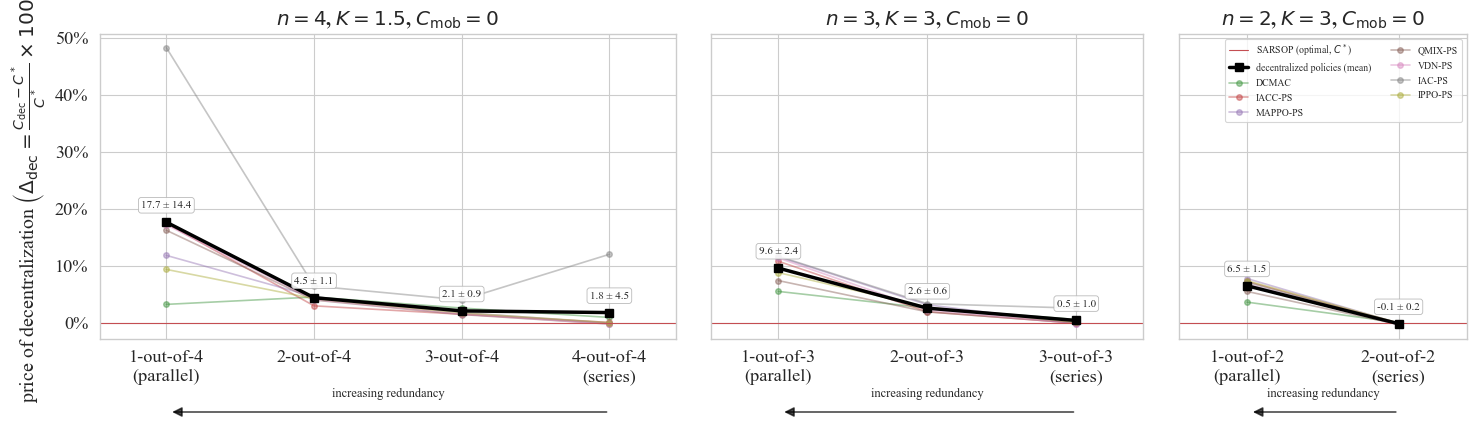

In [4]:
FAMILIES = [
    (
        r"$n=4$, $K=1.5$, $C_{\mathrm{mob}}=0$",
        list(zip(range(1, 5), [f"n4_k{k}_nomob_fpf1.5" for k in range(1, 5)])),
        4,
    ),
    (
        r"$n=3$, $K=3$, $C_{\mathrm{mob}}=0$",
        list(zip(range(1, 4), [f"n3_k{k}_nomob" for k in range(1, 4)])),
        3,
    ),
    (
        r"$n=2$, $K=3$, $C_{\mathrm{mob}}=0$",
        list(zip(range(1, 3), [f"n2_k{k}_nomob" for k in range(1, 3)])),
        2,
    ),
]

fig, axs = plt.subplots(
    1,
    3,
    figsize=(15, 4.6),
    sharey=True,
    gridspec_kw=dict(width_ratios=[len(f[1]) for f in FAMILIES]),
)

for ax, (title, pairs, n) in zip(axs, FAMILIES):
    fam = [s for _, s in pairs]
    piv = best[best.setting.isin(fam)].pivot_table(
        index="algorithm", columns="setting", values="normalized_best_cost"
    )
    piv = piv[fam] * 100  # percent scale, aligned with Delta_dec
    algs = [a for a in ALG_NAMES if a in piv.index]
    x = np.arange(len(fam))

    for alg in algs:
        ax.plot(
            x,
            piv.loc[alg].values,
            marker="o",
            markersize=4,
            lw=1.2,
            alpha=0.45,
            color=ALG_COLORS[alg],
            label=ALG_NAMES[alg],
        )

    mean, std = piv.loc[algs].mean(axis=0).values, piv.loc[algs].std(axis=0).values
    ax.plot(
        x,
        mean,
        marker="s",
        markersize=6,
        lw=2.5,
        color="black",
        zorder=5,
        label="decentralized policies (mean)",
    )
    for xi, mi, si in zip(x, mean, std):
        ax.annotate(
            f"{mi:.1f} ± {si:.1f}",
            (xi, mi),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.25", fc="white", ec="0.7", lw=0.6, alpha=0.9
            ),
            zorder=6,
        )

    ax.axhline(0, color="r", lw=0.8, label=r"SARSOP (optimal, $C^*$)")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            f"{k}-out-of-{n}"
            + ("\n(parallel)" if k == 1 and n > 1 else "")
            + ("\n(series)" if k == n else "")
            for k, _ in pairs
        ]
    )
    ax.set_xlim(-0.45, len(fam) - 0.55)
    ax.set_title(title, fontweight="bold")

    # Redundancy arrow, same convention as the main figure.
    arrow_y = -0.24
    ax.annotate(
        "",
        xy=(0.02, arrow_y),
        xytext=(len(fam) - 1, arrow_y),
        xycoords=ax.get_xaxis_transform(),
        textcoords=ax.get_xaxis_transform(),
        arrowprops=dict(arrowstyle="-|>", color="black", lw=1.2, alpha=0.7),
    )
    ax.text(
        (len(fam) - 1) / 2,
        arrow_y + 0.04,
        "increasing redundancy",
        transform=ax.get_xaxis_transform(),
        fontsize=9,
        ha="center",
        va="bottom",
    )

axs[0].set_ylabel(
    r"price of decentralization $\left( \Delta_{\mathrm{dec}} = \frac{C_{\text{dec}} - C^*}{C^*} \times 100\% \right)$"
)
axs[0].yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

# Shared legend (all panels have the same entries) in the emptiest panel.
handles, labels = axs[0].get_legend_handles_labels()
lead = [
    labels.index(l)
    for l in [r"SARSOP (optimal, $C^*$)", "decentralized policies (mean)"]
]
rest = [i for i in range(len(labels)) if i not in lead]
axs[-1].legend(
    [handles[i] for i in lead + rest],
    [labels[i] for i in lead + rest],
    frameon=True,
    ncol=2,
    fontsize=7,
    loc="upper right",
)

fig.tight_layout()
fig.savefig(FIG_DIR / "pod_vs_redundancy_ablations.pdf", bbox_inches="tight")
plt.show()

## Decision boundaries over the belief simplex (QMIX-PS, VDN-PS)

For each agent, sweep a fine grid of beliefs $b = (\text{no-damage}, \text{minor}, \text{failure})$ over the 2-simplex, holding the other agents fixed, and colour each point by the argmax-Q action. It looks at
- the decision boundary itself -- both algorithms are deterministic value learners, so this is a hard region, not a probabilistic blend
- beliefs actually *visited* during rollouts, overlaid as markers from the same best-seed model as the region (different seeds learn different boundaries)

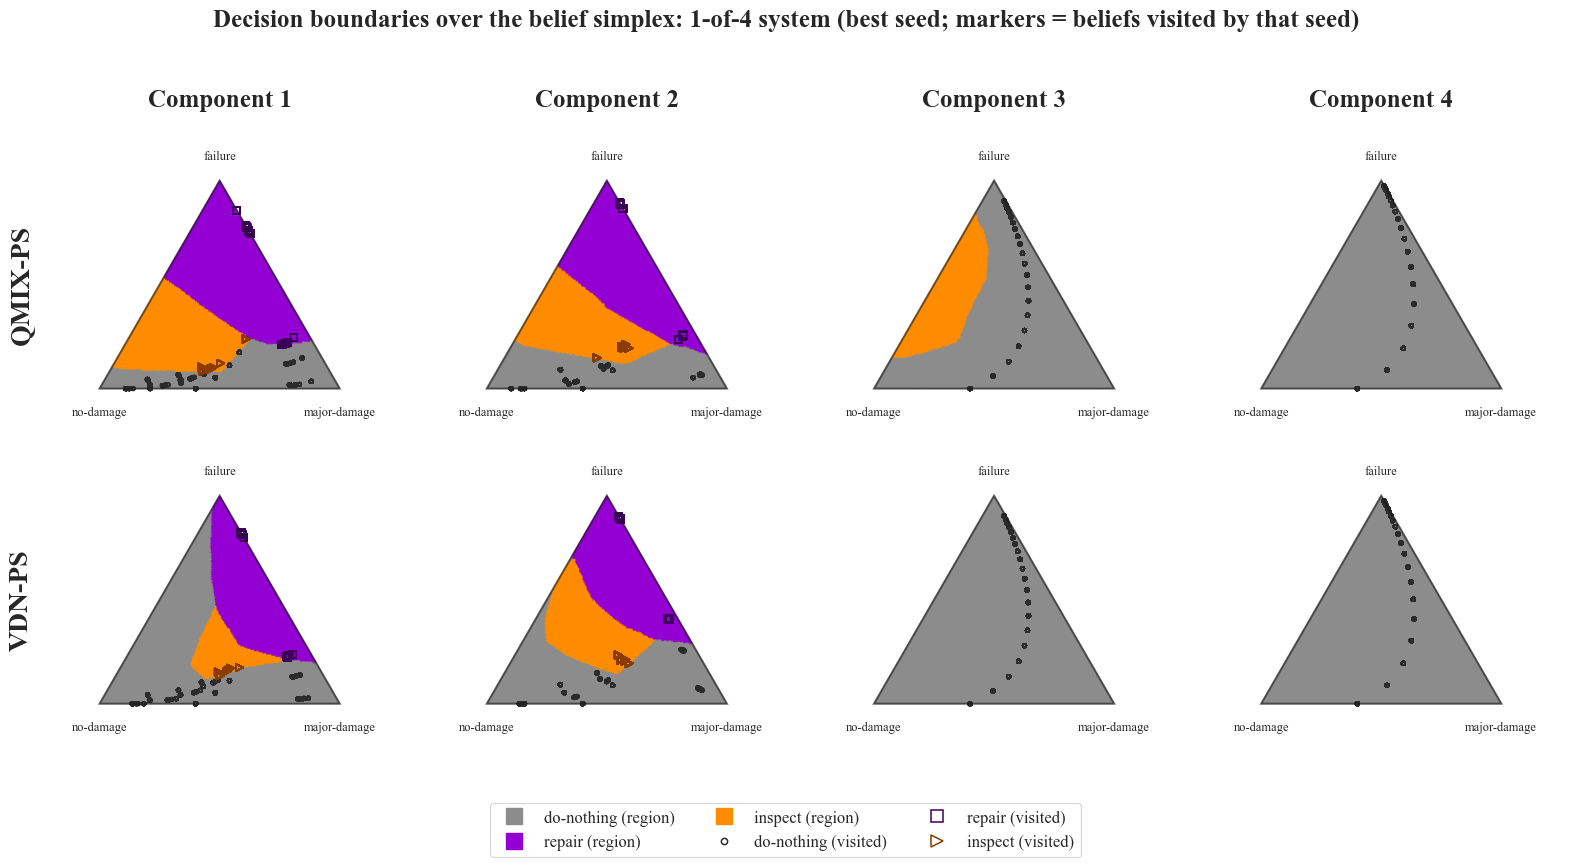

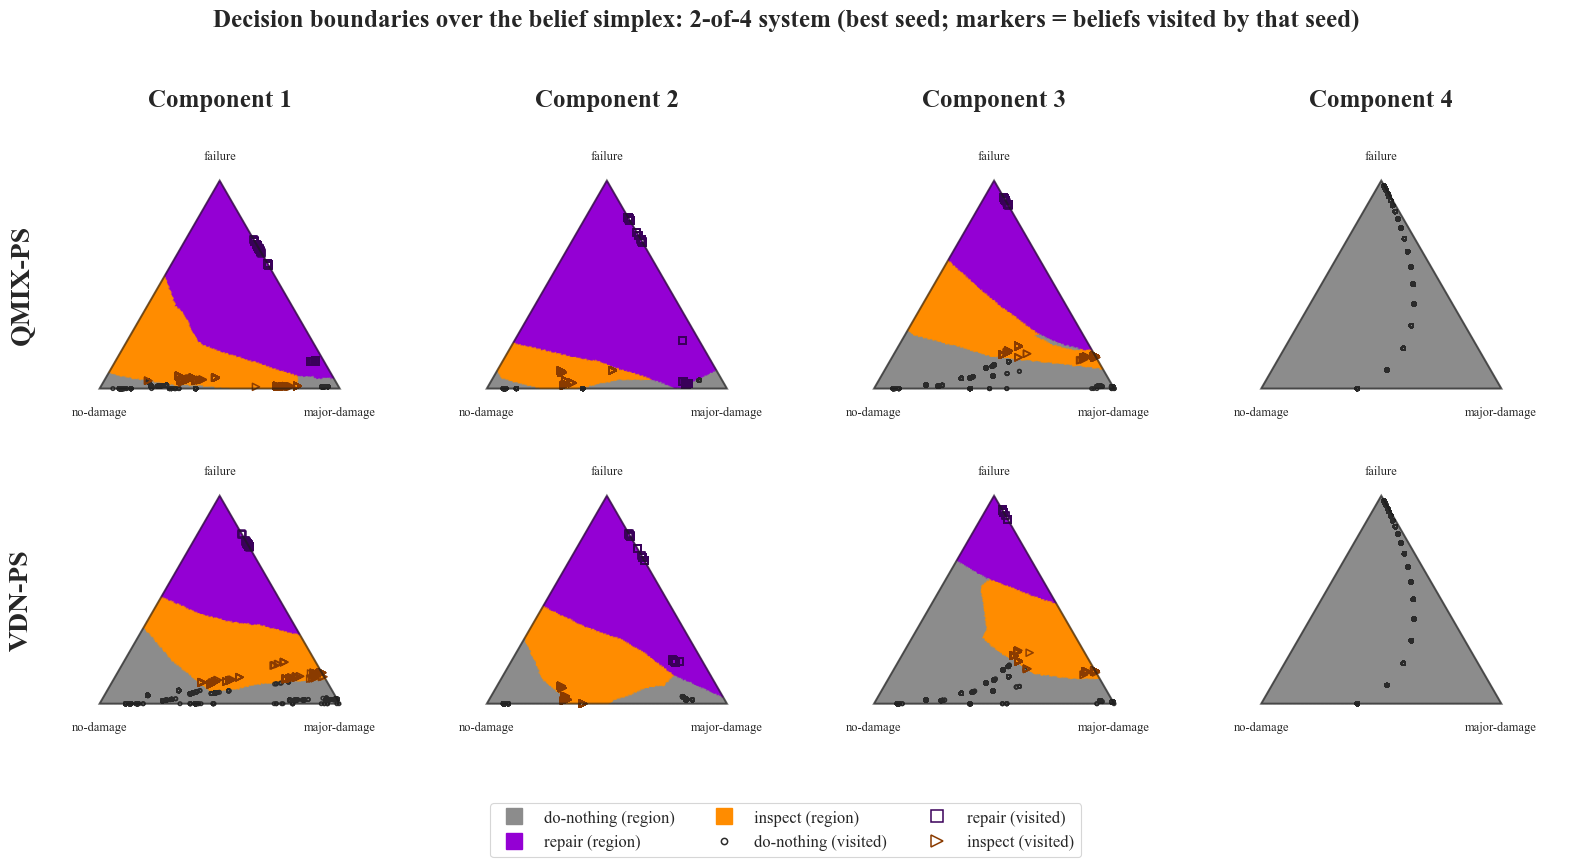

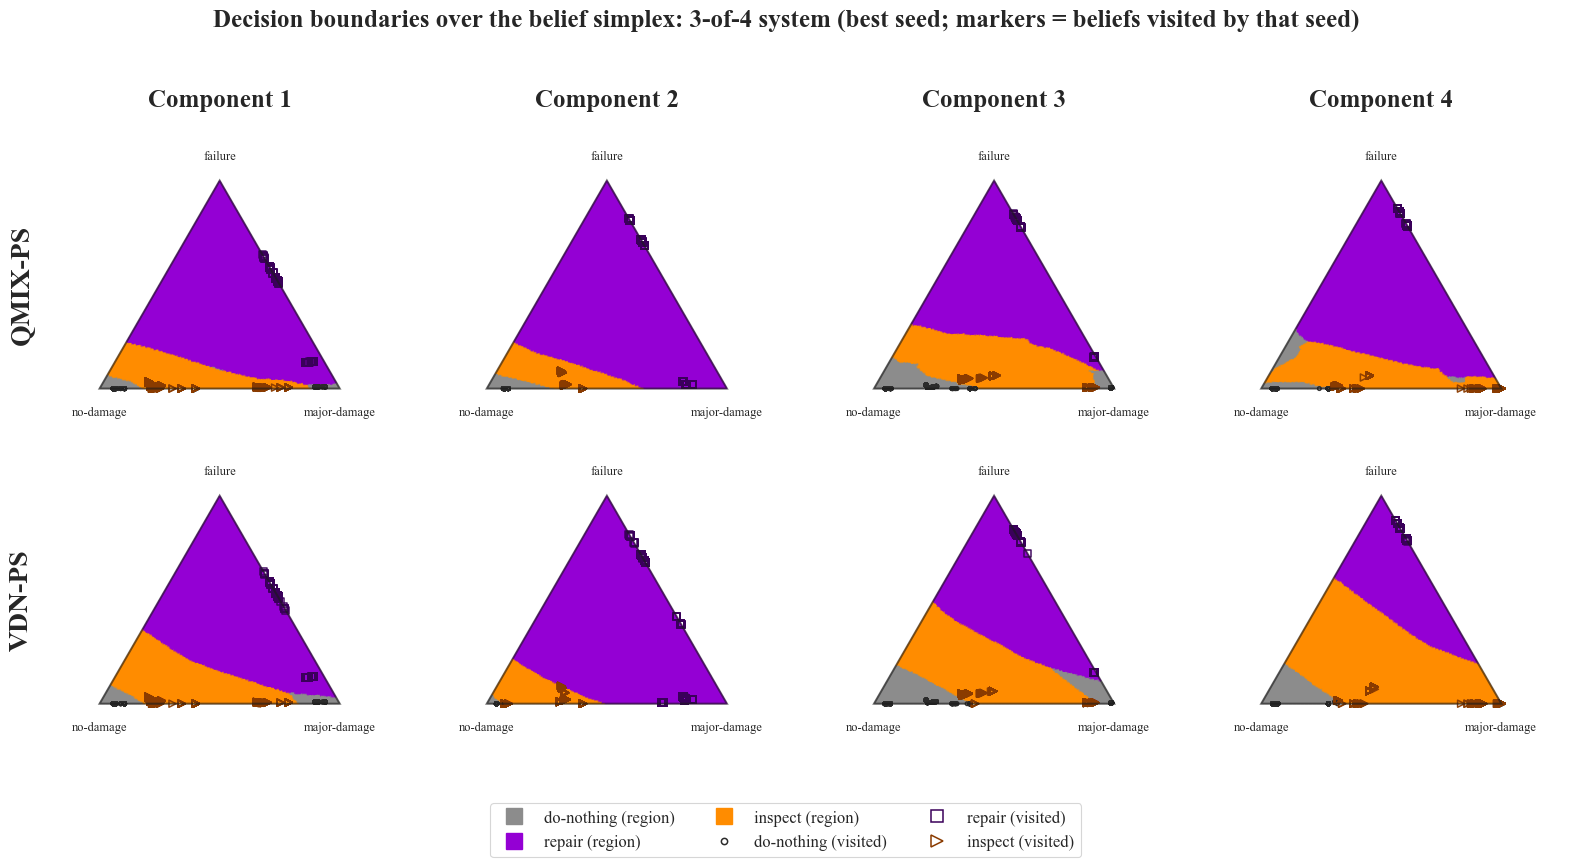

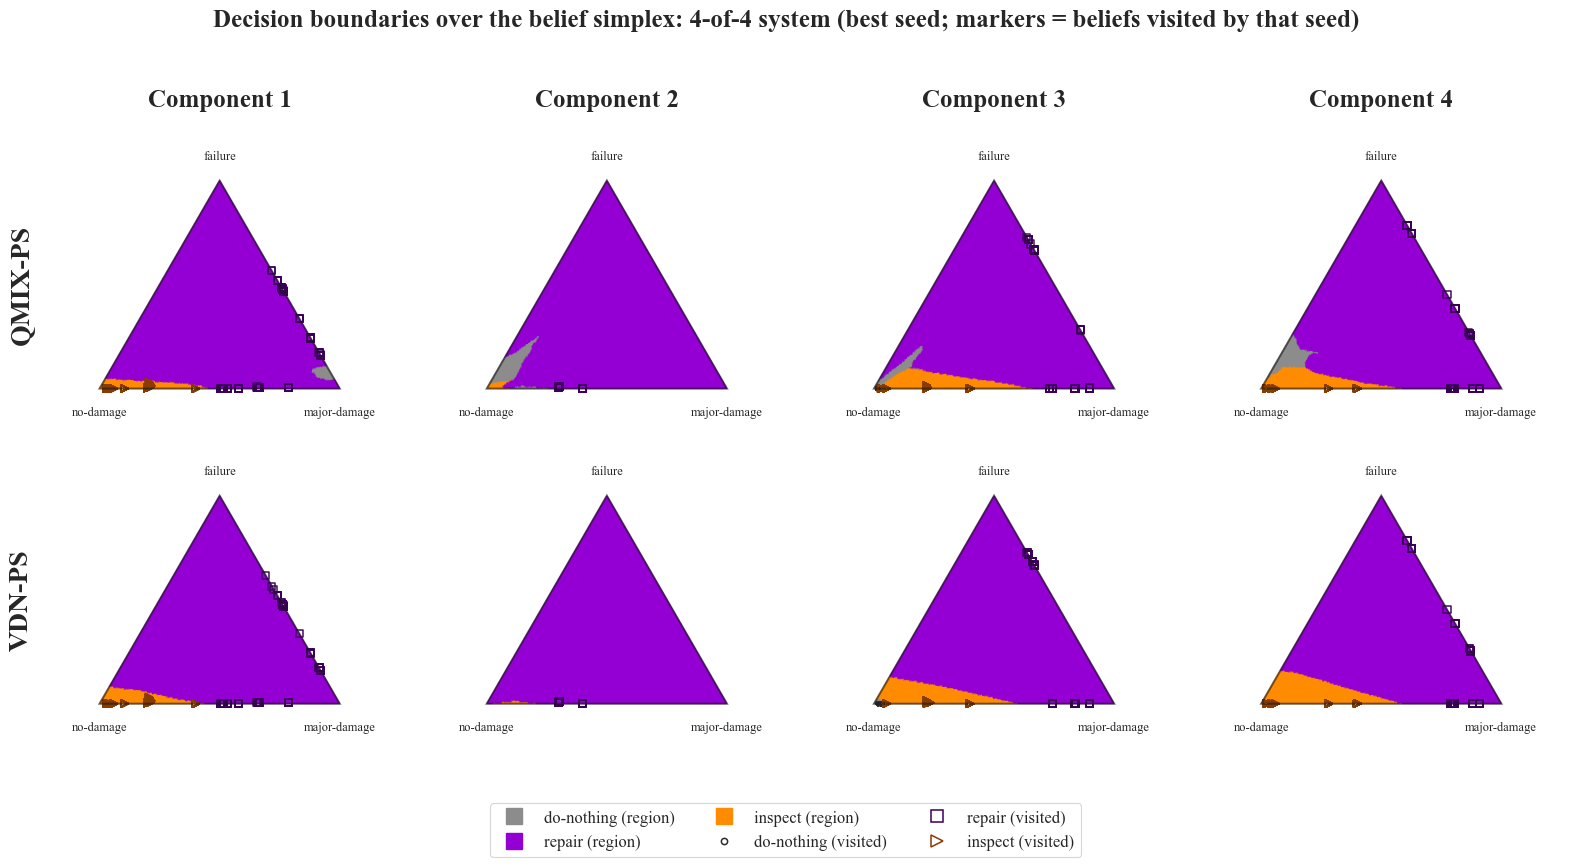

In [5]:
import torch
import yaml
import matplotlib.tri as mtri
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from functools import lru_cache

import imprl.agents

PM_ALGS = [
    "QMIX_PS",
    "VDN_PS",
]  # deterministic value learners -> sharp decision boundaries
N_COMPONENTS = 4
GRID = 180  # simplex resolution; higher -> smoother region boundaries
HEATMAP_ALPHA = 0.2  # decision-region transparency so visited markers stand out
N_ROLLOUT_EPISODES = 100  # visited-belief episodes (best seed) to scatter per panel

# Action colour basis (RGB), order: do-nothing, repair, inspect.
A_RGB = np.array(
    [[0.55, 0.55, 0.55], [0.58, 0.00, 0.83], [1.00, 0.55, 0.00]]
)  # gray, darkviolet, darkorange
A_NAMES = ["do-nothing", "repair", "inspect"]
# Visited-belief markers use the same shapes but dark saturated colours so
# they read on top of the pale region heatmap.
A_MARKERS = [".", "s", ">"]
A_MARKER_COLORS = ["#2b2b2b", "#3a005a", "#8a3b00"]

# 2-simplex -> 2D equilateral triangle (no-damage, minor, failure).
CART = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])


@lru_cache(maxsize=None)
def _build(setting, alg):
    """Load the best-seed env + trained agent for (setting, alg)."""
    sub = summary[(summary.setting == setting) & (summary.algorithm == alg)]
    row = summary.loc[sub["best_cost"].idxmin()]
    rid, ckpt = str(row["run_id"]), int(row["best_checkpoint"])
    rd = REPO_ROOT / "model_checkpoints" / "k_out_of_n_infinite" / setting / alg / rid
    cfg = yaml.safe_load((rd / "config.yaml").read_text())
    ik = dict(
        cfg["ENV_CONFIG"].get("inference_env_kwargs")
        or cfg["ENV_CONFIG"].get("kwargs")
        or {}
    )
    ik["time_limit"] = 20
    env = imprl.envs.make("k_out_of_n_infinite", setting, single_agent=False, **ik)
    agent = imprl.agents.make(alg, env, cfg, torch.device("cpu"))
    agent.load_weights(str(rd / "model_weights"), ckpt)
    return env, agent, rid


@lru_cache(maxsize=None)
def _visited(setting, alg, rid):
    """Beliefs and actions visited by the best-seed model (run id `rid`).

    Returns (beliefs, actions) with beliefs shape (E, T, n_comp, 3) and actions
    shape (E, T, n_comp), or None if that seed's rollout wasn't cached.
    """
    pkl = ALL_SEEDS_ROOT / setting / alg / f"{rid}.pkl"
    if not pkl.exists():
        return None
    with open(pkl, "rb") as f:
        d = pickle.load(f)
    bels, acts = [], []
    for ep in d.values():
        a = np.asarray(ep["actions"])
        bels.append(np.asarray(ep["beliefs"])[: a.shape[0]])  # drop terminal belief
        acts.append(a)
    return np.asarray(bels), np.asarray(acts)


def _simplex_grid(n):
    """Barycentric grid over the simplex and its 2D triangle coordinates."""
    bary = []
    for i in range(n + 1):
        for j in range(n + 1 - i):
            bary.append(np.array([i, j, n - i - j], dtype=float) / n)
    bary = np.array(bary)
    return bary, bary @ CART


def _grid_percepts(env, comp, bary):
    """Vectorised per-agent percepts for the whole belief grid in one array.

    Builds (B, C, 3) beliefs where the probed component sweeps `bary` and the
    others stay at pure no-damage, then the percept encoding the agents use
    (this setting has no time-perception, so it's a plain concatenation).
    """
    B = bary.shape[0]
    C = env.core.n_components
    mp = np.tile(np.array([1.0, 0.0, 0.0], dtype=np.float32), (B, C, 1))
    mp[:, comp, :] = bary  # (B, C, 3)
    eye = np.broadcast_to(np.eye(C, dtype=np.float32), (B, C, C))
    return np.concatenate([eye, mp], axis=2)  # (B, C, C+3)


def _action_probs(env, agent, comp, bary):
    """(B, 3) one-hot argmax-Q rows for one component across the belief grid.

    The probed component varies over the simplex; the others are held at the
    pure no-damage belief. QMIX-PS and VDN-PS are both deterministic greedy
    learners, so the whole grid goes through the Q-network in a single
    batched forward pass and we one-hot the argmax.
    """
    ip = _grid_percepts(env, comp, bary)
    with torch.no_grad():
        q = agent.q_network.forward(torch.as_tensor(ip), training=False)
        P = torch.zeros_like(q[:, comp])
        P[torch.arange(P.shape[0]), q[:, comp].argmax(dim=-1)] = 1.0
    return P.detach().cpu().numpy()


def _blend_rgb(P):
    """Map one-hot action probabilities to their action colour."""
    return np.clip(P @ A_RGB, 0, 1)


def _draw_region_mesh(ax, triang, rgb, alpha):
    """Draw the decision region as one Gouraud-shaded RGBA triangular mesh.

    `tripcolor` only maps a scalar through a colormap, so to render true
    per-vertex RGB we draw a throwaway scalar mesh and overwrite its
    per-vertex colours with our RGBA array.
    """
    rgba = np.concatenate([rgb, np.full((len(rgb), 1), alpha)], axis=1)
    coll = ax.tripcolor(
        triang, np.zeros(triang.x.shape[0]), shading="gouraud", zorder=1
    )
    coll.set_array(None)
    coll.set_facecolor(rgba)  # per-vertex RGBA (Gouraud interpolated)
    return coll


def _style_triangle(ax):
    ax.add_patch(
        Polygon(
            CART, closed=True, fill=None, edgecolor="k", lw=1.5, alpha=0.6, zorder=5
        )
    )
    ax.text(0.0, -0.1, "no-damage", ha="center", va="center", fontsize=9)
    ax.text(1.0, -0.1, "major-damage", ha="center", va="center", fontsize=9)
    ax.text(0.5, np.sqrt(3) / 2 + 0.1, "failure", ha="center", va="center", fontsize=9)
    ax.set_xlim(-0.25, 1.25)
    ax.set_ylim(-0.25, np.sqrt(3) / 2 + 0.25)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)


def plot_policy_maps(setting, save_fig=True):
    bary, pts = _simplex_grid(GRID)
    triang = mtri.Triangulation(pts[:, 0], pts[:, 1])

    fig, axs = plt.subplots(
        len(PM_ALGS),
        N_COMPONENTS,
        figsize=(4.0 * N_COMPONENTS, 4.0 * len(PM_ALGS)),
        squeeze=False,
    )

    for a, alg in enumerate(PM_ALGS):
        env, agent, rid = _build(setting, alg)

        # Visited beliefs from the same best-seed model that defines the region.
        visited = _visited(setting, alg, rid)
        if visited is not None:
            v_bel, v_act = visited
            v_bel = v_bel[:N_ROLLOUT_EPISODES]
            v_act = v_act[:N_ROLLOUT_EPISODES]
            v_xy = v_bel @ CART  # (E, T, n_comp, 2)

        for c in range(N_COMPONENTS):
            ax = axs[a, c]

            # Decision-region heatmap as a single mesh, kept pale so the dark
            # visited markers stand out on top.
            P = _action_probs(env, agent, c, bary)
            _draw_region_mesh(ax, triang, _blend_rgb(P), HEATMAP_ALPHA)

            # Visited beliefs from the best-seed rollout, marked by action taken.
            if visited is not None:
                xy = v_xy[:, :, c, :].reshape(-1, 2)
                act = v_act[:, :, c].reshape(-1)
                for ai in range(3):
                    m = act == ai
                    if not m.any():
                        continue
                    ax.scatter(
                        xy[m, 0],
                        xy[m, 1],
                        marker=A_MARKERS[ai],
                        edgecolors=A_MARKER_COLORS[ai],
                        facecolors="none",
                        linewidths=1.1,
                        s=26,
                        alpha=0.95,
                        zorder=3,
                    )

            _style_triangle(ax)
            if a == 0:
                ax.set_title(
                    f"Component {c + 1}", fontsize=18, fontweight="bold", pad=10
                )
            if c == 0:
                ax.set_ylabel(ALG_NAMES[alg], fontsize=20, fontweight="bold")

    fig.suptitle(
        f"Decision boundaries over the belief simplex: {SETTING_NAMES[setting]} system "
        f"(best seed; markers = beliefs visited by that seed)",
        fontsize=18,
        fontweight="bold",
        y=1.02,
    )

    # Legend: action colour regions + visited-belief markers.
    handles = [
        Line2D(
            [],
            [],
            marker="s",
            color=A_RGB[i],
            ls="None",
            markersize=12,
            label=f"{A_NAMES[i]} (region)",
        )
        for i in range(3)
    ]
    handles += [
        Line2D(
            [],
            [],
            marker=A_MARKERS[i],
            color=A_MARKER_COLORS[i],
            ls="None",
            markerfacecolor="none",
            markeredgewidth=1.1,
            markersize=9,
            label=f"{A_NAMES[i]} (visited)",
        )
        for i in range(3)
    ]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=3,
        fontsize=12,
        bbox_to_anchor=(0.5, -0.05),
    )

    fig.tight_layout(rect=[0, 0.05, 1, 0.98])
    plt.show()

    if save_fig:
        fig.savefig(
            FIG_DIR / f"policy_map_{SETTING_NAMES[setting]}.pdf", bbox_inches="tight"
        )
    return fig


for _setting in SETTINGS:
    plot_policy_maps(_setting, save_fig=True)

## Component-level action patterns (IACC-PS, 1-out-of-4 system)

Each panel is one seed's per-(time step, component) action histogram: share of episodes taking each action, stacked (`do-nothing` omitted, since it's the complement to 100%). It looks at
the periodicity of the learned policies, which is consistent across seeds.

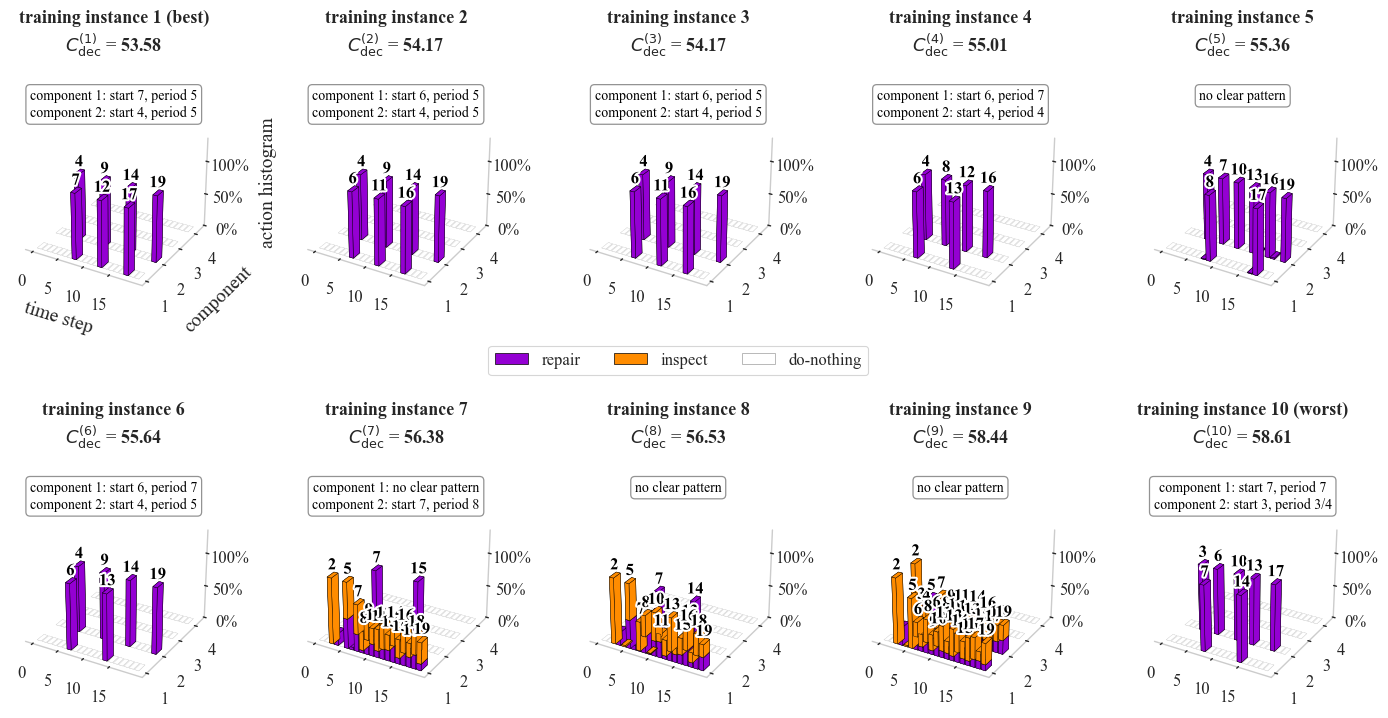

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

DIAG_SETTING = "hard-1-of-4_infinite"
DIAG_ALG = "IACC_PS"
DIAG_ROOT = ALL_SEEDS_ROOT / DIAG_SETTING / DIAG_ALG

diag_rows = (
    summary[(summary.setting == DIAG_SETTING) & (summary.algorithm == DIAG_ALG)]
    .sort_values("best_cost")
    .reset_index(drop=True)
)

# Stacked action layers, drawn bottom-up. do-nothing is omitted (see above).
ACTIONS = [(REPAIR, "repair", "darkviolet"), (INSPECT, "inspect", "darkorange")]
EPS = 1e-9  # below this share, a cell counts as "no action" and is left undrawn

FS_AXLABEL, FS_TICK, FS_TITLE, FS_PEAK, FS_INFO, FS_LEGEND = 14, 12, 13, 12, 10, 12

hist = {}  # run_id -> (T, C, n_layers) share of episodes per action
info_lines = {}  # run_id -> {comp_idx: "component i: start s, period p"}
T = C = None
for _, row in diag_rows.iterrows():
    rid = str(row["run_id"])
    with open(DIAG_ROOT / f"{rid}.pkl", "rb") as f:
        d = pickle.load(f)
    acts = np.stack([np.asarray(e["actions"]) for e in d.values()])  # (E, T, C)
    E, T, C = acts.shape
    hist[rid] = np.stack(
        [(acts == a).mean(axis=0) for a, _, _ in ACTIONS], axis=-1
    )  # (T, C, n_layers)

    comp_counts = (acts == REPAIR).sum(axis=(0, 1))
    lines = {}
    for c in np.where(comp_counts > 0)[0]:
        # Deterministic means every episode repairs at exactly the same
        # timesteps -- this allows an alternating cadence (e.g. gaps 3,4,3,4)
        # as well as a constant one, since requiring a single period value
        # would wrongly reject a schedule that's identical across episodes
        # but not single-period.
        schedules = {tuple(np.where(acts[e, :, c] == REPAIR)[0]) for e in range(E)}
        t = np.asarray(next(iter(schedules))) if len(schedules) == 1 else None
        if t is None or len(t) < 2:
            lines[c] = f"component {c + 1}: no clear pattern"
            continue
        gaps = "/".join(str(int(g)) for g in sorted(set(np.diff(t).tolist())))
        lines[c] = f"component {c + 1}: start {int(t[0])}, period {gaps}"
    info_lines[rid] = lines

vmax = max(h.sum(axis=-1).max() for h in hist.values())
label_stroke = [pe.withStroke(linewidth=3.0, foreground="white")]

NCOLS = 5
fig = plt.figure(figsize=(13.5, 7.2))
# Component-axis spacing: bars stay 0.6 deep, but the rows are pushed apart
# so the four components read as clearly separate lanes.
YGAP = 2.0
xs, cidx = np.meshgrid(np.arange(T), np.arange(C), indexing="ij")
xs, cidx = xs.ravel(), cidx.ravel()
ys = cidx * YGAP

for i, (_, row) in enumerate(diag_rows.iterrows()):
    rid = str(row["run_id"])
    ax = fig.add_subplot(2, NCOLS, i + 1, projection="3d")

    # Stack the action layers bottom-up, drawing only cells where that action
    # actually occurs (zero-height bars would otherwise render as flat
    # colored strips across the idle components).
    h = hist[rid]  # (T, C, n_layers)
    base = np.zeros(len(xs))
    for layer, (_, _, colour) in enumerate(ACTIONS):
        dz = h[:, :, layer].ravel()
        m = dz > EPS
        if m.any():
            ax.bar3d(
                xs[m],
                ys[m],
                base[m],
                0.8,
                0.7,
                dz[m],
                color=colour,
                shade=False,
                edgecolor="black",
                linewidth=0.3,
            )
        base = base + dz

    # Cells where nothing ever happens are drawn as flat white footprints
    # with a very light border: this keeps the grid visible without adding
    # ink, and staying at zero height means they never occlude bars behind them.
    idle = base <= EPS
    if idle.any():
        ax.bar3d(
            xs[idle],
            ys[idle],
            np.zeros(idle.sum()),
            0.8,
            0.7,
            0.0,
            color="white",
            shade=False,
            edgecolor="0.82",
            linewidth=0.2,
        )

    ax.set_zlim(0, vmax * 1.35)  # headroom so peak labels never reach the info box

    comp_lines = info_lines[rid]
    totals = h.sum(axis=-1).ravel()
    for t, ci, y, z in zip(xs, cidx, ys, totals):
        if ci in comp_lines and z >= 0.3 * vmax:
            ax.text(
                t + 0.4,
                y + 0.3,
                z + 0.03 * vmax,
                str(t),
                fontsize=FS_PEAK,
                fontweight="bold",
                ha="center",
                va="bottom",
                zorder=10,
                color="black",
                path_effects=label_stroke,
            )

    # Deterministic components get their period/start printed above the panel;
    # otherwise say explicitly that there's no clear pattern.
    lines = info_lines[rid]
    caption = (
        "no clear pattern"
        if not lines or all("no clear pattern" in v for v in lines.values())
        else "\n".join(lines[c] for c in sorted(lines))
    )
    ax.text2D(
        0.5,
        1.02,
        caption,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=FS_INFO,
        color="black",
        linespacing=1.3,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.55", lw=0.9, alpha=0.94),
    )

    # Axis labels on the first panel only -- all ten panels share the same
    # axes. Raised zorder makes this panel draw last so its (externally
    # placed) labels aren't painted over by the next panel.
    if i == 0:
        ax.set_xlabel("time step", fontsize=FS_AXLABEL, labelpad=5)
        ax.set_ylabel("component", fontsize=FS_AXLABEL, labelpad=8)
        ax.text2D(
            1.2,
            0.57,
            "action histogram",
            transform=ax.transAxes,
            rotation=90,
            ha="left",
            va="center",
            fontsize=FS_AXLABEL,
        )
        ax.set_zorder(100)

    ax.zaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_zticks([0, 0.5, 1.0])
    ax.set_yticks(np.arange(C) * YGAP)
    ax.set_yticklabels([str(c + 1) for c in range(C)], fontsize=FS_TICK)
    ax.set_xticks(np.arange(0, T, 5))
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.tick_params(axis="z", labelsize=FS_TICK, pad=2)

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor("none")
    ax.grid(False)

    ax.view_init(elev=28, azim=-60)
    rank = i + 1
    tag = f"training instance {rank}" + (
        " (best)" if rank == 1 else " (worst)" if rank == len(diag_rows) else ""
    )
    ax.set_title(
        f"{tag}\n$C_{{\\mathrm{{dec}}}}^{{({rank})}}$ = {row['best_cost']:.2f}",
        fontsize=FS_TITLE,
        fontweight="bold",
        pad=30,
    )

legend_handles = [
    Patch(facecolor=colour, edgecolor="black", linewidth=0.5, label=label)
    for _, label, colour in ACTIONS
] + [Patch(facecolor="white", edgecolor="0.72", linewidth=0.7, label="do-nothing")]

# fig.tight_layout() doesn't size 3D axes reliably, so margins are set by hand.
# Tighter inter-panel spacing (rather than a bigger figure) enlarges the
# panels while keeping the font:figure-width ratio -- and therefore the
# rendered point size in the paper -- unchanged.
fig.subplots_adjust(
    left=0.005, right=0.995, top=0.90, bottom=0.05, wspace=0.36, hspace=0.78
)

# Legend in the band between the two rows, anchored to the measured row
# geometry so it stays centred if the layout changes.
row0 = fig.axes[0].get_position()
row1 = fig.axes[NCOLS].get_position()
fig.legend(
    handles=legend_handles,
    loc="center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.5 * (row0.y0 + row1.y1) + 0.045),
    fontsize=FS_LEGEND,
)
fig.savefig(FIG_DIR / "iacc_ps_component_action_hist_3d.pdf", bbox_inches="tight")
plt.show()